<a href="https://colab.research.google.com/github/halgekishan/linear-Regression/blob/main/model_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [ ]:
df=pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df=df.drop(['PassengerId','Name','Ticket','Cabin'],axis=1, errors='ignore')

In [ ]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [ ]:
df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [ ]:
df.Age.fillna(df.Age.mean(), inplace=True)
df.Fare.fillna(df.Fare.mean(), inplace=True)
df.Embarked.fillna(df.Embarked.mode()[0], inplace=True)

/tmp/ipykernel_3240/3017344236.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Fare.fillna(df.Fare.mean(), inplace=True)


In [ ]:
df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [ ]:
df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [ ]:
df['Sex']=df['Sex'].replace({'male':0,'female':1})
df['Embarked']=df['Embarked'].replace({'S':0,'C':1,'Q':2})

/tmp/ipykernel_3240/3002377168.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Embarked']=df['Embarked'].replace({'S':0,'C':1,'Q':2})


In [ ]:
print(df.head())
df.tail()

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    0  22.0      1      0   7.2500         0
1         1       1    1  38.0      1      0  71.2833         1
2         1       3    1  26.0      0      0   7.9250         0
3         1       1    1  35.0      1      0  53.1000         0
4         0       3    0  35.0      0      0   8.0500         0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
886,0,2,0,27.000000,0,0,13.00,0
887,1,1,1,19.000000,0,0,30.00,0
888,0,3,1,29.699118,1,2,23.45,0
889,1,1,0,26.000000,0,0,30.00,1
890,0,3,0,32.000000,0,0,7.75,2


# Model Tarin

In [ ]:
x=df.drop('Survived',axis=1)
y=df['Survived']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

In [ ]:
scalar=StandardScaler()
x_train=scalar.fit_transform(x_train)
x_test=scalar.transform(x_test)

# LOGISTIC REGRASSION

In [46]:
lr=LogisticRegression(max_iter=1000)
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
accuracy_score(y_test, y_pred)

0.8097014925373134

# **KNN**

In [49]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)
y_pred_knn = knn.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

Accuracy: 0.8059701492537313


## **DECESION TREE**

In [52]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

Accuracy: 0.7798507462686567


# **Random Forest**

In [54]:
rd=RandomForestClassifier()
rd.fit(x_train,y_train)
y_pred_rd=rd.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred_rd))

Accuracy: 0.832089552238806


# **final accuracy**

In [57]:
print("Logistic:", accuracy_score(y_test, y_pred))
print("KNN:", accuracy_score(y_test, y_pred_knn))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred))

Logistic: 0.8097014925373134
KNN: 0.8059701492537313
Decision Tree: 0.7798507462686567
Random Forest: 0.8097014925373134


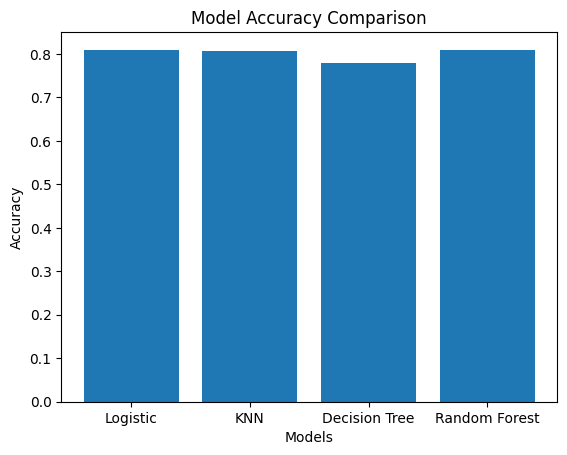

In [59]:
models = ['Logistic', 'KNN', 'Decision Tree', 'Random Forest']
scores = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred)
]



plt.bar(models, scores)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()